

\

# **ml project**



# Load data

In [29]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
df = pd.read_csv('/content/karnataka_aadhar_biometrics.csv')

# Corrected column assignment based on the error and common CSV structures
# Assuming the CSV columns are: index, state, district, pincode, bio_age_5_17, bio_age_17_plus, date
df.columns = ['index', 'state', 'district', 'pincode', 'bio_age_5_17', 'bio_age_17_plus', 'date']
df = df.drop('index', axis=1, errors='ignore')
df['date'] = pd.to_datetime(df['date'],  format='mixed', dayfirst=True, errors='coerce')

# Drop rows where 'date' is NaT
df.dropna(subset=['date'], inplace=True)

# Single numeric column
df['date_encoded'] = df['date'].apply(lambda x: x.toordinal())
df

,state,district,pincode,bio_age_5_17,bio_age_17_plus,date,date_encoded
74239,Karnataka,Davangere,577002,219,386,1970-01-01 00:00:00.000000030,719163
74240,Karnataka,Mysuru,571602,117,131,1970-01-01 00:00:00.000000051,719163
74241,Karnataka,Uttara Kannada,581344,15,7,1970-01-01 00:00:00.000000060,719163
74242,Karnataka,Udupi,574114,16,16,1970-01-01 00:00:00.000000062,719163
74243,Karnataka,Tumakuru,572225,16,3,1970-01-01 00:00:00.000000066,719163
...,...,...,...,...,...,...,...
112558,Karnataka,Yadgir,585304,2,3,1970-01-01 00:00:00.000498467,719163
112559,Karnataka,Yadgir,585315,4,11,1970-01-01 00:00:00.000498468,719163
112560,Karnataka,Yadgir,585323,5,4,1970-01-01 00:00:00.000498469,719163
112561,Karnataka,yadgir,585201,0,6,1970-01-01 00:00:00.000498470,719163


In [30]:
df = df.drop('date', axis=1)
df = df.drop('state', axis=1)


le_district = LabelEncoder()
df['district_label'] = le_district.fit_transform(df['district'])
df



,district,pincode,bio_age_5_17,bio_age_17_plus,date_encoded,district_label
74239,Davangere,577002,219,386,719163,25
74240,Mysuru,571602,117,131,719163,40
74241,Uttara Kannada,581344,15,7,719163,49
74242,Udupi,574114,16,16,719163,47
74243,Tumakuru,572225,16,3,719163,45
...,...,...,...,...,...,...
112558,Yadgir,585304,2,3,719163,52
112559,Yadgir,585315,4,11,719163,52
112560,Yadgir,585323,5,4,719163,52
112561,yadgir,585201,0,6,719163,53


In [31]:
df_karnataka = df[df['district']=="Yadgir"]
print(len(df_karnataka))
df_karnataka




472


,district,pincode,bio_age_5_17,bio_age_17_plus,date_encoded,district_label
74342,Yadgir,585223,272,246,719163,52
74660,Yadgir,585215,219,191,719163,52
74665,Yadgir,585216,328,340,719163,52
74674,Yadgir,585321,210,259,719163,52
74683,Yadgir,585214,187,166,719163,52
...,...,...,...,...,...,...
112191,Yadgir,585237,5,5,719163,52
112557,Yadgir,585287,7,4,719163,52
112558,Yadgir,585304,2,3,719163,52
112559,Yadgir,585315,4,11,719163,52


#data perparations



##Data separation as X and Y



In [32]:
y = df_karnataka[['bio_age_17_plus','bio_age_5_17']]
y

,bio_age_17_plus,bio_age_5_17
74342,246,272
74660,191,219
74665,340,328
74674,259,210
74683,166,187
...,...,...
112191,5,5
112557,4,7
112558,3,2
112559,11,4


In [33]:
x = df_karnataka.drop(['bio_age_17_plus','bio_age_5_17','district'],axis=1)
x

,pincode,date_encoded,district_label
74342,585223,719163,52
74660,585215,719163,52
74665,585216,719163,52
74674,585321,719163,52
74683,585214,719163,52
...,...,...,...
112191,585237,719163,52
112557,585287,719163,52
112558,585304,719163,52
112559,585315,719163,52


In [34]:
x = df_karnataka.drop(['district'],axis=1)
x

,pincode,bio_age_5_17,bio_age_17_plus,date_encoded,district_label
74342,585223,272,246,719163,52
74660,585215,219,191,719163,52
74665,585216,328,340,719163,52
74674,585321,210,259,719163,52
74683,585214,187,166,719163,52
...,...,...,...,...,...
112191,585237,5,5,719163,52
112557,585287,7,4,719163,52
112558,585304,2,3,719163,52
112559,585315,4,11,719163,52


###data spliting


In [35]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=100)

In [36]:
x_train


,pincode,bio_age_5_17,bio_age_17_plus,date_encoded,district_label
76556,585291,126,103,719163,52
74674,585321,210,259,719163,52
104351,585223,23,23,719163,52
74794,585237,132,112,719163,52
102344,585215,2,0,719163,52
...,...,...,...,...,...
102346,585315,1,2,719163,52
103502,585202,8,2,719163,52
100348,585323,5,2,719163,52
96875,585319,10,2,719163,52


In [37]:
x_test

,pincode,bio_age_5_17,bio_age_17_plus,date_encoded,district_label
94706,585219,1,1,719163,52
92150,585216,4,6,719163,52
109668,585220,1,5,719163,52
91095,585216,2,1,719163,52
101745,585214,5,11,719163,52
...,...,...,...,...,...
91300,585323,0,1,719163,52
89684,585291,2,2,719163,52
87093,585317,1,0,719163,52
76881,585309,198,132,719163,52


## model building


###linear regression


##Training the model

In [38]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

**applying the model**

In [39]:
y_lr_train_pred = lr.predict(x_train)
y_lr_test_pred = lr.predict(x_test)


In [40]:
y_lr_train_pred


array([[ 1.03000000e+02,  1.26000000e+02],
       [ 2.59000000e+02,  2.10000000e+02],
       [ 2.30000000e+01,  2.30000000e+01],
       [ 1.12000000e+02,  1.32000000e+02],
       [-1.64891799e-14,  2.00000000e+00],
       [ 9.00000000e+00,  1.10000000e+01],
       [ 2.00000000e+00, -2.88883401e-14],
       [ 6.00000000e+00,  7.00000000e+00],
       [ 1.17000000e+02,  2.31000000e+02],
       [ 1.43000000e+02,  1.56000000e+02],
       [ 2.76000000e+02,  2.65000000e+02],
       [ 2.00000000e+00,  1.00000000e+00],
       [ 1.91000000e+02,  2.19000000e+02],
       [ 9.00000000e+00,  2.20000000e+01],
       [ 8.00000000e+00,  7.00000000e+00],
       [ 9.00000000e+01,  1.01000000e+02],
       [ 5.00000000e+00,  3.00000000e+00],
       [ 1.41000000e+02,  1.24000000e+02],
       [ 1.00000000e+00,  4.00000000e+00],
       [ 1.10000000e+02,  2.18000000e+02],
       [ 1.20000000e+01,  4.00000000e+00],
       [ 1.10000000e+01,  2.00000000e+00],
       [ 1.00000000e+01,  1.10000000e+01],
       [-1.

In [41]:
y_lr_test_pred

array([[ 1.00000000e+00,  1.00000000e+00],
       [ 6.00000000e+00,  4.00000000e+00],
       [ 5.00000000e+00,  1.00000000e+00],
       [ 1.00000000e+00,  2.00000000e+00],
       [ 1.10000000e+01,  5.00000000e+00],
       [ 6.50000000e+01,  1.26000000e+02],
       [ 2.06000000e+02,  2.62000000e+02],
       [ 3.00000000e+00,  3.00000000e+00],
       [-1.56043111e-14,  7.00000000e+00],
       [ 1.40000000e+01,  5.00000000e+00],
       [ 3.00000000e+00,  6.00000000e+00],
       [ 1.10000000e+01,  1.00000000e+00],
       [ 6.00000000e+00,  8.00000000e+00],
       [ 7.00000000e+00,  5.00000000e+00],
       [ 1.20000000e+01,  4.00000000e+00],
       [ 3.00000000e+00,  2.00000000e+00],
       [ 3.10000000e+01,  4.60000000e+01],
       [ 4.68000000e+02,  3.94000000e+02],
       [ 2.00000000e+00,  2.00000000e+00],
       [ 3.00000000e+00, -3.06897787e-14],
       [ 4.00000000e+00,  7.00000000e+00],
       [ 8.00000000e+00,  8.00000000e+00],
       [-1.67667357e-14,  7.00000000e+00],
       [ 6.

#  Evaluate model performance

In [42]:
y_train

,bio_age_17_plus,bio_age_5_17
76556,103,126
74674,259,210
104351,23,23
74794,112,132
102344,0,2
...,...,...
102346,2,1
103502,2,8
100348,2,5
96875,2,10


In [43]:
from sklearn.metrics import mean_squared_error ,r2_score

lr_train_mse = mean_squared_error(y_train,y_lr_train_pred)
lr_train_r2 = r2_score(y_train,y_lr_train_pred)

lr_test_mse = mean_squared_error(y_test,y_lr_test_pred)
lr_test_r2 = r2_score(y_test,y_lr_test_pred)

In [44]:
print('LR MSE(Train):' , lr_train_mse)
print("LR R2 (Train): ",lr_train_r2)
print('LR MSE(Test):' , lr_test_mse)
print("LR R2 (Test): ",lr_test_r2)

LR MSE(Train): 5.641551202817242e-28
LR R2 (Train):  1.0
LR MSE(Test): 7.3603612814854745e-28
LR R2 (Test):  1.0


In [45]:
lr_result = pd.DataFrame(['Linear Regression',lr_train_mse,lr_train_r2,lr_test_mse,lr_test_r2]).transpose()
lr_result.columns = ['Method','Training MSE','Training R2','Testing MSE','Testing R2']

In [46]:
lr_result

,Method,Training MSE,Training R2,Testing MSE,Testing R2
0,Linear Regression,0.0,1.0,0.0,1.0


## **Random Forest**

## Training the model

In [47]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(max_depth=2, random_state=100)
rf.fit(x_train, y_train)


RandomForestRegressor(max_depth=2, random_state=100)

# Applying the model to make performance

In [48]:
y_rf_train_pred = rf.predict(x_train)
y_rf_test_pred = rf.predict(x_test)

**Evaluate the model**

In [49]:
from sklearn.metrics import mean_squared_error ,r2_score

rf_train_mse = mean_squared_error(y_train,y_rf_train_pred)
rf_train_r2 = r2_score(y_train,y_rf_train_pred)

rf_test_mse = mean_squared_error(y_test,y_rf_test_pred)
rf_test_r2 = r2_score(y_test,y_rf_test_pred)

In [50]:
rf_result = pd.DataFrame(['Random Forest',rf_train_mse,rf_train_r2,rf_test_mse,rf_test_r2]).transpose()
rf_result.columns = ['Method','Training MSE','Training R2','Testing MSE','Testing R2']
rf_result

,Method,Training MSE,Training R2,Testing MSE,Testing R2
0,Random Forest,495.298488,0.937576,585.33694,0.946598


**MODEL COMPARISION**

In [51]:
final_df_model = pd.concat([lr_result,rf_result],axis=0)
final_df_model.columns = ['Methods','Training MSE','Training R2','Testing MSE','Testing R2']
final_df_model
final_df_model.reset_index(drop=True)

,Methods,Training MSE,Training R2,Testing MSE,Testing R2
0,Linear Regression,0.0,1.0,0.0,1.0
1,Random Forest,495.298488,0.937576,585.33694,0.946598


# Data visualization of Prediction results

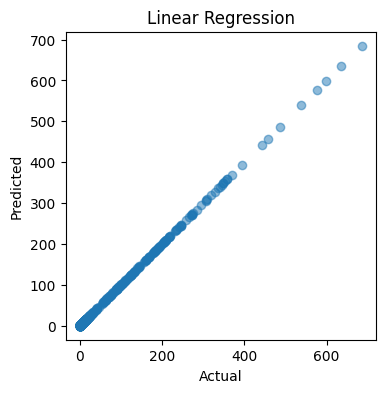

In [52]:
import matplotlib.pyplot as plt
plt.figure(figsize=(4,4))
plt.scatter(x=y_train, y=y_lr_train_pred,alpha=0.5)
plt.plot()
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Linear Regression')
plt.show()

# New model training


In [13]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
df = pd.read_csv('/content/karnataka_aadhar_demographic.csv')

df.columns = [ 'date', 'state', 'district', 'pincode', 'demo_age_5_17', 'demo_age_17_']
df = df.drop('index', axis=1, errors='ignore')
df['date'] = pd.to_datetime(df['date'], format='mixed', dayfirst=True)

# Single numeric column
df['date_encoded'] = df['date'].apply(lambda x: x.toordinal())

df

,date,state,district,pincode,demo_age_5_17,demo_age_17_,date_encoded
0,2025-11-02,Karnataka,Bagalkot,587101,1,2,739557
1,2025-11-02,Karnataka,Bagalkot,587103,3,5,739557
2,2025-11-02,Karnataka,Bagalkot,587112,0,1,739557
3,2025-11-02,Karnataka,Bagalkot,587201,1,2,739557
4,2025-11-02,Karnataka,Bagalkot,587203,4,2,739557
...,...,...,...,...,...,...,...
111489,2025-10-31,Karnataka,Yadgir,585315,0,7,739555
111490,2025-10-31,Karnataka,Yadgir,585319,2,10,739555
111491,2025-10-31,Karnataka,yadgir,585201,0,2,739555
111492,2025-10-31,Karnataka,yadgir,585221,0,2,739555


In [14]:
df = df.drop('date', axis=1)
df = df.drop('state', axis=1)


le_district = LabelEncoder()
df['district_label'] = le_district.fit_transform(df['district'])
df


,district,pincode,demo_age_5_17,demo_age_17_,date_encoded,district_label
0,Bagalkot,587101,1,2,739557,0
1,Bagalkot,587103,3,5,739557,0
2,Bagalkot,587112,0,1,739557,0
3,Bagalkot,587201,1,2,739557,0
4,Bagalkot,587203,4,2,739557,0
...,...,...,...,...,...,...
111489,Yadgir,585315,0,7,739555,53
111490,Yadgir,585319,2,10,739555,53
111491,yadgir,585201,0,2,739555,54
111492,yadgir,585221,0,2,739555,54


In [15]:
df_karnataka = df[df['district']=="Yadgir"]
print(len(df_karnataka))
df_karnataka


1389


,district,pincode,demo_age_5_17,demo_age_17_,date_encoded,district_label
263,Yadgir,585201,0,1,739557,53
264,Yadgir,585237,0,1,739557,53
265,Yadgir,585315,0,1,739557,53
621,Yadgir,585202,5,16,739558,53
622,Yadgir,585216,13,20,739558,53
...,...,...,...,...,...,...
111486,Yadgir,585215,12,25,739555,53
111487,Yadgir,585216,13,14,739555,53
111488,Yadgir,585237,3,14,739555,53
111489,Yadgir,585315,0,7,739555,53


In [16]:
y = df_karnataka[[ 'demo_age_5_17', 'demo_age_17_']]
y

,demo_age_5_17,demo_age_17_
263,0,1
264,0,1
265,0,1
621,5,16
622,13,20
...,...,...
111486,12,25
111487,13,14
111488,3,14
111489,0,7


In [29]:
avg_enrollments = df_karnataka[['demo_age_5_17', 'demo_age_17_']].mean(axis=1)

print(df_karnataka[['district', 'pincode', 'demo_age_5_17', 'demo_age_17_', 'avg_enrollments']].head())

    district  pincode  demo_age_5_17  demo_age_17_  avg_enrollments
263   Yadgir   585201              0             1              0.5
264   Yadgir   585237              0             1              0.5
265   Yadgir   585315              0             1              0.5
621   Yadgir   585202              5            16             10.5
622   Yadgir   585216             13            20             16.5


In [41]:
avg_child = df['demo_age_5_17'].mean()
avg_adult = df['demo_age_17_'].mean()

overall_avg = (df['demo_age_5_17'].sum() + df['demo_age_17_'].sum()) / (2 * len(df))

print(f"Average child enrollments: {avg_child:.2f}")
print(f"Average adult enrollments: {avg_adult:.2f}")
print(f"Overall average enrollment: {overall_avg:.2f}")


Average child enrollments: 1.59
Average adult enrollments: 8.76
Overall average enrollment: 5.17


# Demographic Averages by District + Pincode

In [37]:
grouped_avg = df_karnataka.groupby(['district', 'pincode'])[['demo_age_5_17', 'demo_age_17_']].mean().round(2)

grouped_avg['total_enrollments_avg'] = grouped_avg['demo_age_5_17'] + grouped_avg['demo_age_17_']
grouped_avg['overall_avg'] = grouped_avg[['demo_age_5_17', 'demo_age_17_']].mean(axis=1)
child_percentage = (grouped_avg['demo_age_5_17'] / grouped_avg['overall_avg'] * 100).round(1)

print(grouped_avg.sort_values('total_enrollments_avg', ascending=False).head(20))

                  demo_age_5_17  demo_age_17_  total_enrollments_avg  \
district pincode                                                       
Yadgir   585202           14.47         48.95                  63.42   
         585223            8.03         30.36                  38.39   
         585216            7.29         23.26                  30.55   
         585215            5.11         14.95                  20.06   
         585221            4.00         14.97                  18.97   
         585321            3.09         15.58                  18.67   
         585214            2.31         13.04                  15.35   
         585290            2.77         12.50                  15.27   
         585309            2.74         12.06                  14.80   
         585237            2.93          9.60                  12.53   
         585355            1.40          9.83                  11.23   
         585323            2.32          8.84                  1

In [42]:
A= df_karnataka.drop(['demo_age_5_17', 'demo_age_17_','district','avg_enrollments_per_row'],axis=1)
A

,pincode,date_encoded,district_label,avg_enrollments
263,585201,739557,53,0.5
264,585237,739557,53,0.5
265,585315,739557,53,0.5
621,585202,739558,53,10.5
622,585216,739558,53,16.5
...,...,...,...,...
111486,585215,739555,53,18.5
111487,585216,739555,53,13.5
111488,585237,739555,53,8.5
111489,585315,739555,53,3.5


In [ ]:
# x = df_karnataka.drop(['district'],axis=1)
# x

,pincode,demo_age_5_17,demo_age_17_,date_encoded,district_label
263,585201,0,1,739557,52
264,585237,0,1,739557,52
265,585315,0,1,739557,52
621,585202,5,16,739558,52
622,585216,13,20,739558,52
...,...,...,...,...,...
111486,585215,12,25,739555,52
111487,585216,13,14,739555,52
111488,585237,3,14,739555,52
111489,585315,0,7,739555,52


**DATA SPLITING**

In [46]:
features = [
    'district_label',
    'pincode',
    'demo_age_5_17',     # Child enrollments help predict adult
    'date_encoded',
    'avg_enrollments'

]

x = df_karnataka[features]
y = df_karnataka['demo_age_17_']

x



,district_label,pincode,demo_age_5_17,date_encoded,avg_enrollments
263,53,585201,0,739557,0.5
264,53,585237,0,739557,0.5
265,53,585315,0,739557,0.5
621,53,585202,5,739558,10.5
622,53,585216,13,739558,16.5
...,...,...,...,...,...
111486,53,585215,12,739555,18.5
111487,53,585216,13,739555,13.5
111488,53,585237,3,739555,8.5
111489,53,585315,0,739555,3.5


 **Train-Test Split**


In [47]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=100)


**training with x**

In [48]:
x_train

,district_label,pincode,demo_age_5_17,date_encoded,avg_enrollments
104668,53,585214,3,739537,3.0
68235,53,585218,1,739586,6.5
19019,53,585319,1,739499,3.0
11035,53,585355,3,739597,3.5
69586,53,585319,1,739589,3.5
...,...,...,...,...,...
62886,53,585309,9,739559,9.5
4571,53,585290,1,739569,8.5
25963,53,585224,0,739545,0.5
7091,53,585218,0,739588,2.5


**testing with x**

In [49]:
x_test

,district_label,pincode,demo_age_5_17,date_encoded,avg_enrollments
104673,53,585309,1,739537,1.5
44862,53,585287,1,739611,3.5
27694,53,585287,0,739551,2.0
21269,53,585315,0,739507,1.0
24729,53,585220,1,739541,1.5
...,...,...,...,...,...
39806,53,585309,4,739595,8.0
65950,53,585290,2,739568,6.0
67879,53,585319,2,739586,2.5
57134,53,585215,1,739543,2.5


**traning with y**

In [50]:
y_train

,demo_age_17_
104668,3
68235,12
19019,5
11035,4
69586,6
...,...
62886,10
4571,16
25963,1
7091,5


**testing with y**

In [52]:
y_test

,demo_age_17_
104673,2
44862,6
27694,4
21269,2
24729,2
...,...
39806,12
65950,10
67879,3
57134,4


# model building

##linear regression

# Training the model

In [53]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

### applying the model

In [54]:
y_lr_train_pred = lr.predict(x_train)
y_lr_test_pred = lr.predict(x_test)

In [57]:
y_lr_train_pred

array([ 3., 12.,  5., ...,  1.,  5.,  5.])

In [56]:
y_lr_test_pred

array([ 2.00000000e+00,  6.00000000e+00,  4.00000000e+00,  2.00000000e+00,
        2.00000000e+00,  2.00000000e+00,  4.00000000e+00,  1.00000000e+00,
        1.00000000e+00,  1.80000000e+01,  1.00000000e+00,  4.00000000e+00,
        1.30000000e+01,  3.00000000e+00,  2.00000000e+00,  1.00000000e+00,
        2.00000000e+00,  2.30000000e+01,  2.00000000e+00,  4.00000000e+00,
        1.10000000e+01,  9.00000000e+00,  3.00000000e+00,  1.60000000e+01,
        1.00000000e+01,  1.00000000e+00,  1.00000000e+00,  2.00000000e+00,
        1.90000000e+01,  5.00000000e+00,  6.00000000e+00,  9.00000000e+00,
        1.00000000e+00,  1.20000000e+01,  1.00000000e+01,  5.00000000e+00,
        4.00000000e+00,  9.00000000e+00,  2.00000000e+00,  7.00000000e+00,
        4.00000000e+00,  8.00000000e+00,  4.00000000e+00,  1.00000000e+00,
        4.00000000e+00,  2.20000000e+01,  5.00000000e+00,  1.30000000e+01,
        8.00000000e+00,  1.00000000e+00,  1.00000000e+00,  2.30000000e+01,
        1.80000000e+01,  

# Evaluate model performance

In [60]:
y_train

,demo_age_17_
104668,3
68235,12
19019,5
11035,4
69586,6
...,...
62886,10
4571,16
25963,1
7091,5


In [61]:
from sklearn.metrics import mean_squared_error ,r2_score

lr_train_mse = mean_squared_error(y_train,y_lr_train_pred)
lr_train_r2 = r2_score(y_train,y_lr_train_pred)

lr_test_mse = mean_squared_error(y_test,y_lr_test_pred)
lr_test_r2 = r2_score(y_test,y_lr_test_pred)

In [62]:
print('LR MSE(Train):' , lr_train_mse)
print("LR R2 (Train): ",lr_train_r2)
print('LR MSE(Test):' , lr_test_mse)
print("LR R2 (Test): ",lr_test_r2)

LR MSE(Train): 5.888557882828252e-28
LR R2 (Train):  1.0
LR MSE(Test): 6.178510554825478e-28
LR R2 (Test):  1.0


In [63]:
lr_result = pd.DataFrame(['Linear Regression',lr_train_mse,lr_train_r2,lr_test_mse,lr_test_r2]).transpose()
lr_result.columns = ['Method','Training MSE','Training R2','Testing MSE','Testing R2']

In [64]:
lr_result

,Method,Training MSE,Training R2,Testing MSE,Testing R2
0,Linear Regression,0.0,1.0,0.0,1.0


# Random Forest

**Training the model**

In [71]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(max_depth=2, random_state=100)
rf.fit(x_train, y_train)

RandomForestRegressor(max_depth=2, random_state=100)

In [66]:
y_rf_train_pred = rf.predict(x_train)
y_rf_test_pred = rf.predict(x_test)

**Evaluate the model**

In [84]:
from sklearn.metrics import mean_squared_error ,r2_score

rf_train_mse = mean_squared_error(y_train,y_rf_train_pred)
rf_train_r2 = r2_score(y_train,y_rf_train_pred)

rf_test_mse = mean_squared_error(y_test,y_rf_test_pred)
rf_test_r2 = (f'{r2_score(y_test,y_rf_test_pred):.4f}')

In [85]:
rf_result = pd.DataFrame(['Random Forest',rf_train_mse,rf_train_r2,rf_test_mse,rf_test_r2]).transpose()
rf_result.columns = ['Method','Training MSE','Training R2','Testing MSE','Testing R2']
rf_result

,Method,Training MSE,Training R2,Testing MSE,Testing R2
0,Random Forest,45.940174,0.97682,72.690495,0.9362


**ADDING XGBOOST MODEL**

**for better performance result**

In [99]:
from xgboost import XGBRegressor
XGB = XGBRegressor(
    max_depth=2,
    random_state=100
)
XGB.fit(x_train, y_train)
print("XGBoost training complete!")

XGBoost training complete!


In [100]:
y_xgb_train_pred = XGB.predict(x_train)
y_xgb_test_pred = XGB.predict(x_test)

In [103]:
from sklearn.metrics import mean_squared_error ,r2_score

xgb_train_mse = mean_squared_error(y_train,y_xgb_train_pred)
xgb_train_r2 = r2_score(y_train,y_xgb_train_pred)

xgb_test_mse = mean_squared_error(y_test,y_xgb_test_pred)
xgb_test_r2 = (f'{r2_score(y_test,y_xgb_test_pred):.4f}')

**final Evaluation**

In [104]:
xgb_result = pd.DataFrame(['XGBoost',xgb_train_mse,xgb_train_r2,xgb_test_mse,xgb_test_r2]).transpose()
xgb_result.columns = ['Method','Training MSE','Training R2','Testing MSE','Testing R2']
xgb_result

,Method,Training MSE,Training R2,Testing MSE,Testing R2
0,XGBoost,0.101974,0.999949,64.854881,0.9431


# MODEL COMPARISION

In [105]:
final_df_model = pd.concat([lr_result,rf_result,xgb_result],axis=0)
final_df_model.columns = ['Methods','Training MSE','Training R2','Testing MSE','Testing R2']
final_df_model
final_df_model.reset_index(drop=True)

,Methods,Training MSE,Training R2,Testing MSE,Testing R2
0,Linear Regression,0.0,1.0,0.0,1.0
1,Random Forest,45.940174,0.97682,72.690495,0.9362
2,XGBoost,0.101974,0.999949,64.854881,0.9431


# Data visualization of Prediction results

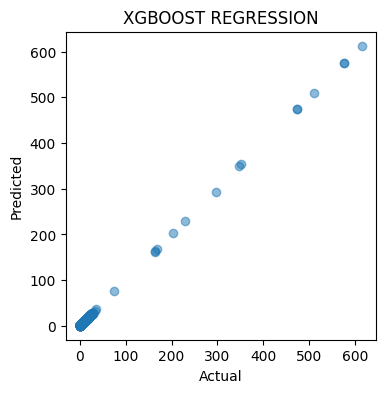

In [110]:
import matplotlib.pyplot as plt
plt.figure(figsize=(4,4))
plt.scatter(x=y_train, y=y_xgb_train_pred,alpha=0.5)
plt.plot()
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('XGBOOST REGRESSION')
plt.show()